In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import zipfile

zip_path = "/content/drive/MyDrive/animal-faces/animal-faces.zip"
extract_path = "/content/animal-faces"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Selesai extract!")

Selesai extract!


In [33]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available:", device)

Device Available: cuda


In [34]:
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])


transform_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [35]:
train_dataset = datasets.ImageFolder(
    root="/content/animal-faces/afhq/train",
    transform=transform_train
)

val_dataset = datasets.ImageFolder(
    root="/content/animal-faces/afhq/val",
    transform=transform_val
)

val_size = int(len(val_dataset) * 0.5)
test_size = len(val_dataset) - val_size
val_dataset, test_dataset = torch.utils.data.random_split(val_dataset, [val_size, test_size])

print(f"Train: {len(train_dataset)} foto")
print(f"Val:   {len(val_dataset)} foto")
print(f"Test:  {len(test_dataset)} foto")

Train: 14630 foto
Val:   750 foto
Test:  750 foto


In [36]:
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [37]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pooling = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.flatten = nn.Flatten()
        self.linear = nn.Linear(128*16*16, 256)
        self.dropout = nn.Dropout(0.5)
        self.output = nn.Linear(256, 3)

    def forward(self, x):
        x = self.relu(self.bn1(self.pooling(self.conv1(x))))
        x = self.relu(self.bn2(self.pooling(self.conv2(x))))
        x = self.relu(self.bn3(self.pooling(self.conv3(x))))

        x = self.flatten(x)
        x = self.dropout(self.relu(self.linear(x)))
        x = self.output(x)
        return x

model = Net().to(device)
print("Model siap!")

Model siap!


In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

best_val_loss = float('inf')
patience = 4
counter = 0

train_loss_plot, val_loss_plot = [], []
train_acc_plot, val_acc_plot = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss_train, total_acc_train = 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss_train += loss.item()
        total_acc_train += (torch.argmax(outputs, 1) == labels).sum().item()

    model.eval()
    total_loss_val, total_acc_val = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss_val += loss.item()
            total_acc_val += (torch.argmax(outputs, 1) == labels).sum().item()

    avg_train_loss = total_loss_train / len(train_loader)
    avg_val_loss   = total_loss_val   / len(val_loader)
    avg_train_acc  = total_acc_train  / len(train_dataset) * 100
    avg_val_acc    = total_acc_val    / len(val_dataset)   * 100

    train_loss_plot.append(avg_train_loss)
    val_loss_plot.append(avg_val_loss)
    train_acc_plot.append(avg_train_acc)
    val_acc_plot.append(avg_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly stopping! Training berhenti di epoch {epoch+1}")
            break

print("\nTraining selesai!")

Epoch 1/15 | Train Loss: 0.3452 Acc: 86.35% | Val Loss: 0.1235 Acc: 95.60%
Epoch 2/15 | Train Loss: 0.1432 Acc: 94.72% | Val Loss: 0.1194 Acc: 95.60%
Epoch 3/15 | Train Loss: 0.1172 Acc: 95.81% | Val Loss: 0.0971 Acc: 96.67%
Epoch 4/15 | Train Loss: 0.0899 Acc: 96.89% | Val Loss: 0.0790 Acc: 97.33%
Epoch 5/15 | Train Loss: 0.0812 Acc: 97.04% | Val Loss: 0.0680 Acc: 97.47%
Epoch 6/15 | Train Loss: 0.0740 Acc: 97.51% | Val Loss: 0.0669 Acc: 97.87%
Epoch 7/15 | Train Loss: 0.0696 Acc: 97.47% | Val Loss: 0.0693 Acc: 97.60%
Epoch 8/15 | Train Loss: 0.0625 Acc: 97.79% | Val Loss: 0.0668 Acc: 98.00%
Epoch 9/15 | Train Loss: 0.0579 Acc: 97.75% | Val Loss: 0.0624 Acc: 98.40%
Epoch 10/15 | Train Loss: 0.0572 Acc: 97.98% | Val Loss: 0.0769 Acc: 98.00%
Epoch 11/15 | Train Loss: 0.0524 Acc: 98.06% | Val Loss: 0.0642 Acc: 98.00%
Epoch 12/15 | Train Loss: 0.0480 Acc: 98.35% | Val Loss: 0.0546 Acc: 98.40%
Epoch 13/15 | Train Loss: 0.0452 Acc: 98.30% | Val Loss: 0.0725 Acc: 98.00%
Epoch 14/15 | Train L

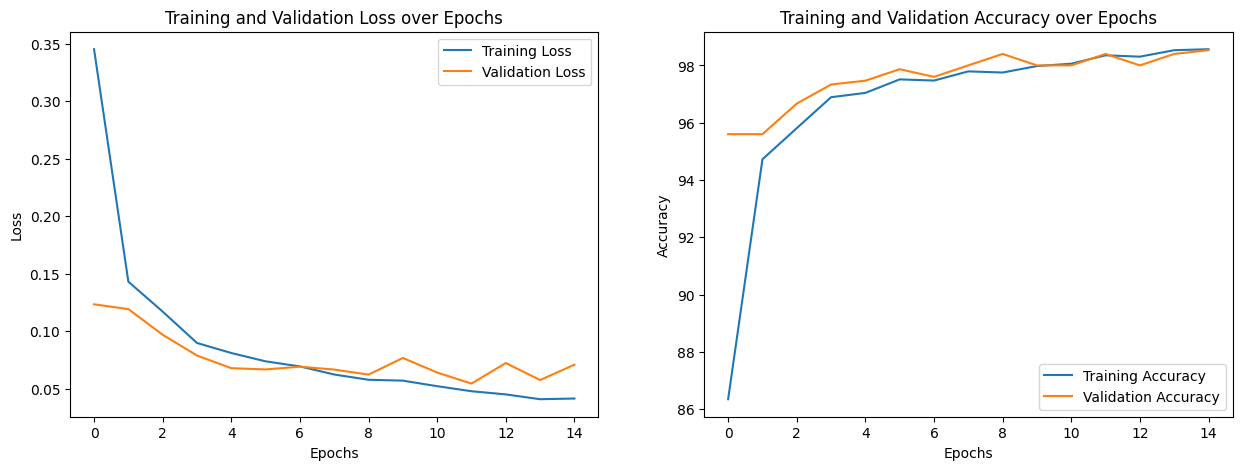

In [39]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(train_loss_plot, label='Training Loss')
axs[0].plot(val_loss_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(train_acc_plot, label='Training Accuracy')
axs[1].plot(val_acc_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [40]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

total_acc_test = 0
total_loss_test = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        total_loss_test += loss.item()
        total_acc_test += (torch.argmax(outputs, 1) == labels).sum().item()

acc = total_acc_test / len(test_dataset) * 100
print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 98.53%


In [44]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("Model loaded!")

Model loaded!


In [46]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform_val(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, axis=1).item()

    classes = {0: 'cat', 1: 'dog', 2: 'wild'}
    return classes[pred]

predict_image("/content/dog1.jpg")

'dog'

In [47]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform_val(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, axis=1).item()

    classes = {0: 'cat', 1: 'dog', 2: 'wild'}
    return classes[pred]

predict_image("/content/dog2.jpg")

'dog'

In [48]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform_val(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, axis=1).item()

    classes = {0: 'cat', 1: 'dog', 2: 'wild'}
    return classes[pred]

predict_image("/content/cat.jpg")

'cat'

In [53]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform_val(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, axis=1).item()

    classes = {0: 'cat', 1: 'dog', 2: 'wild'}
    return classes[pred]

predict_image("/content/tiger.jpg")

'wild'

In [43]:
!pip install gradio --quiet

In [54]:
import gradio as gr

def predict(image):
    image = Image.fromarray(image).convert('RGB')
    image_tensor = transform_val(image).to(device)
    model.eval()
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0))
        probs = torch.softmax(output, dim=1)[0]
    classes = ['cat', 'dog', 'wild']
    result = {classes[i]: float(probs[i]) for i in range(len(classes))}
    return result

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(label="Upload Foto Hewan"),
    outputs=gr.Label(label="Hasil Prediksi", num_top_classes=3),
    title="Animal Face Classifier",
    description="Upload foto hewan untuk diklasifikasikan!"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e2a39c25c89f088152.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
